In [1]:
import numpy as np
import scipy.stats
import pylab as plt
plt.rcParams['figure.figsize'] = [8, 8]

from matplotlib import pyplot as plt

from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson

from astropy.visualization import hist
from astropy.stats import median_absolute_deviation

from astroML import stats as astroMLstats
from astroML.plotting import setup_text_plots
from tqdm.notebook import tqdm

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=14, usetex=True)
%config InlineBackend.figure_format='retina'

/home/lorenzo/Desktop/repos/python_ambient/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


### 1. A nasty integral

Using Monte Carlo integration, check that

$$ \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

- Does the result converge with the number of samples? And how does the error go down?
- Do it many times. For a given $N$, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks *very* accurate! And if $N$ is small?)
- How does the distribution change if $N$ increases?

(Hint: think about sample mean and sample variance)

Ci serve una gaussiana correttamente normalizzata tra 0 e +infinito, pertanto usiamo la forma funzionale della gaussiana con media 0 e sigma 
$p(x) = \frac{2}{\sigma \sqrt{2 \pi}} \cdot exp(-\frac{x^2}{2*\sigma^2})$

In questo modo I diventa $ I = \sigma \sqrt{\frac{\pi}{2}} \cdot \int_0^{+\infty} x^3 p(x) dx$

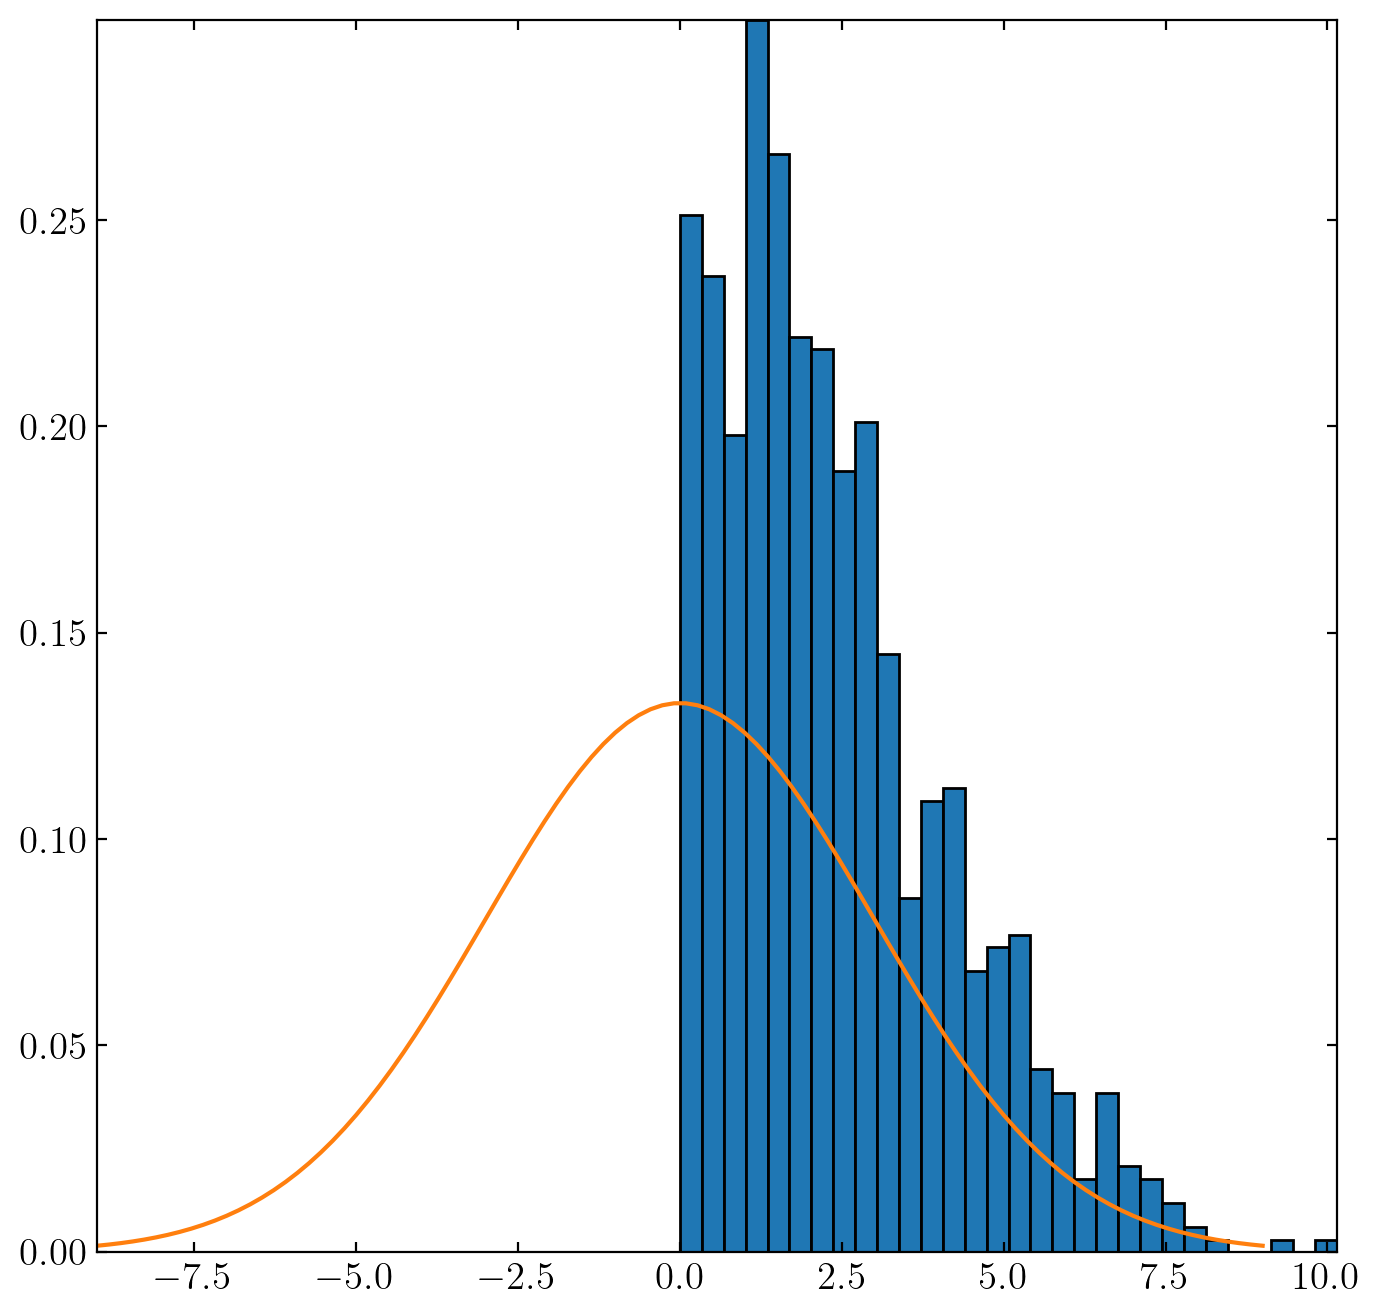

In [3]:
#generiamo da una gaussiana con un sigma 
sigma = 3
N = 1000

#generiamo la distribuzione con scipy
gauss = scipy.stats.norm(loc = 0, scale = sigma)

#verifichiamo che siano generati gaussianamente
plt.hist(np.abs(gauss.rvs(N)), density = True, bins = 30);
plt.plot(np.linspace(-3*sigma,3*sigma,100), np.abs(gauss.pdf(np.linspace(-3*sigma,3*sigma,100))))

In [4]:
samples = np.abs(gauss.rvs(N))
I = sigma*(np.pi/2)**0.5 * np.mean(samples**3)
est_result = 2*sigma**4

print(I, est_result, np.abs(I-est_result)/est_result)

163.03223899958232 162 0.006371845676434066


In [5]:
def integral(sigma, N):
    gauss = scipy.stats.norm(loc=0,scale=sigma)
    samples = np.abs(gauss.rvs(N))
    norm = sigma*(np.pi/2)**0.5
    return norm * np.mean(samples**3) 

def est_result(sigma):
    return 2*sigma**4

In [6]:
sigma = 0.45
Nvals=np.unique(np.logspace(0,6,100,dtype=int))
results = np.array([integral(sigma,N) for N in tqdm(Nvals)])

  0%|          | 0/92 [00:00<?, ?it/s]

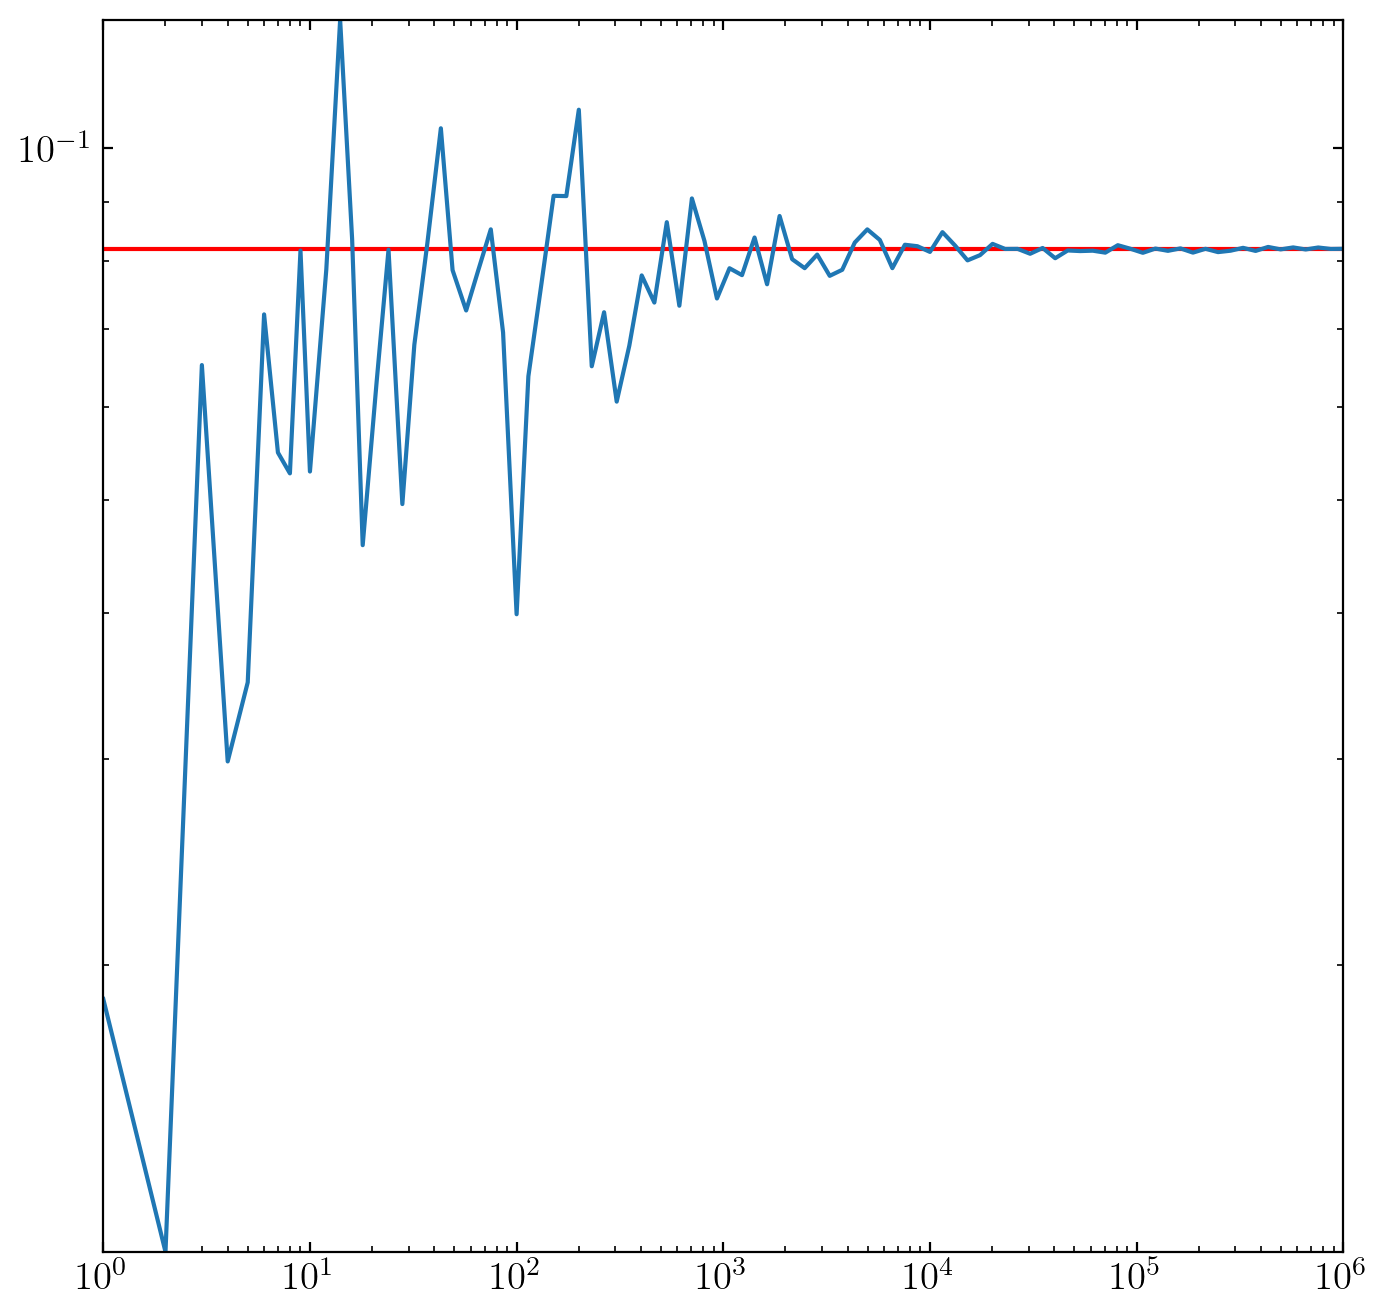

In [7]:
plt.axhline(est_result(sigma),c='red')
plt.plot(Nvals,results)
plt.loglog()
plt.show()

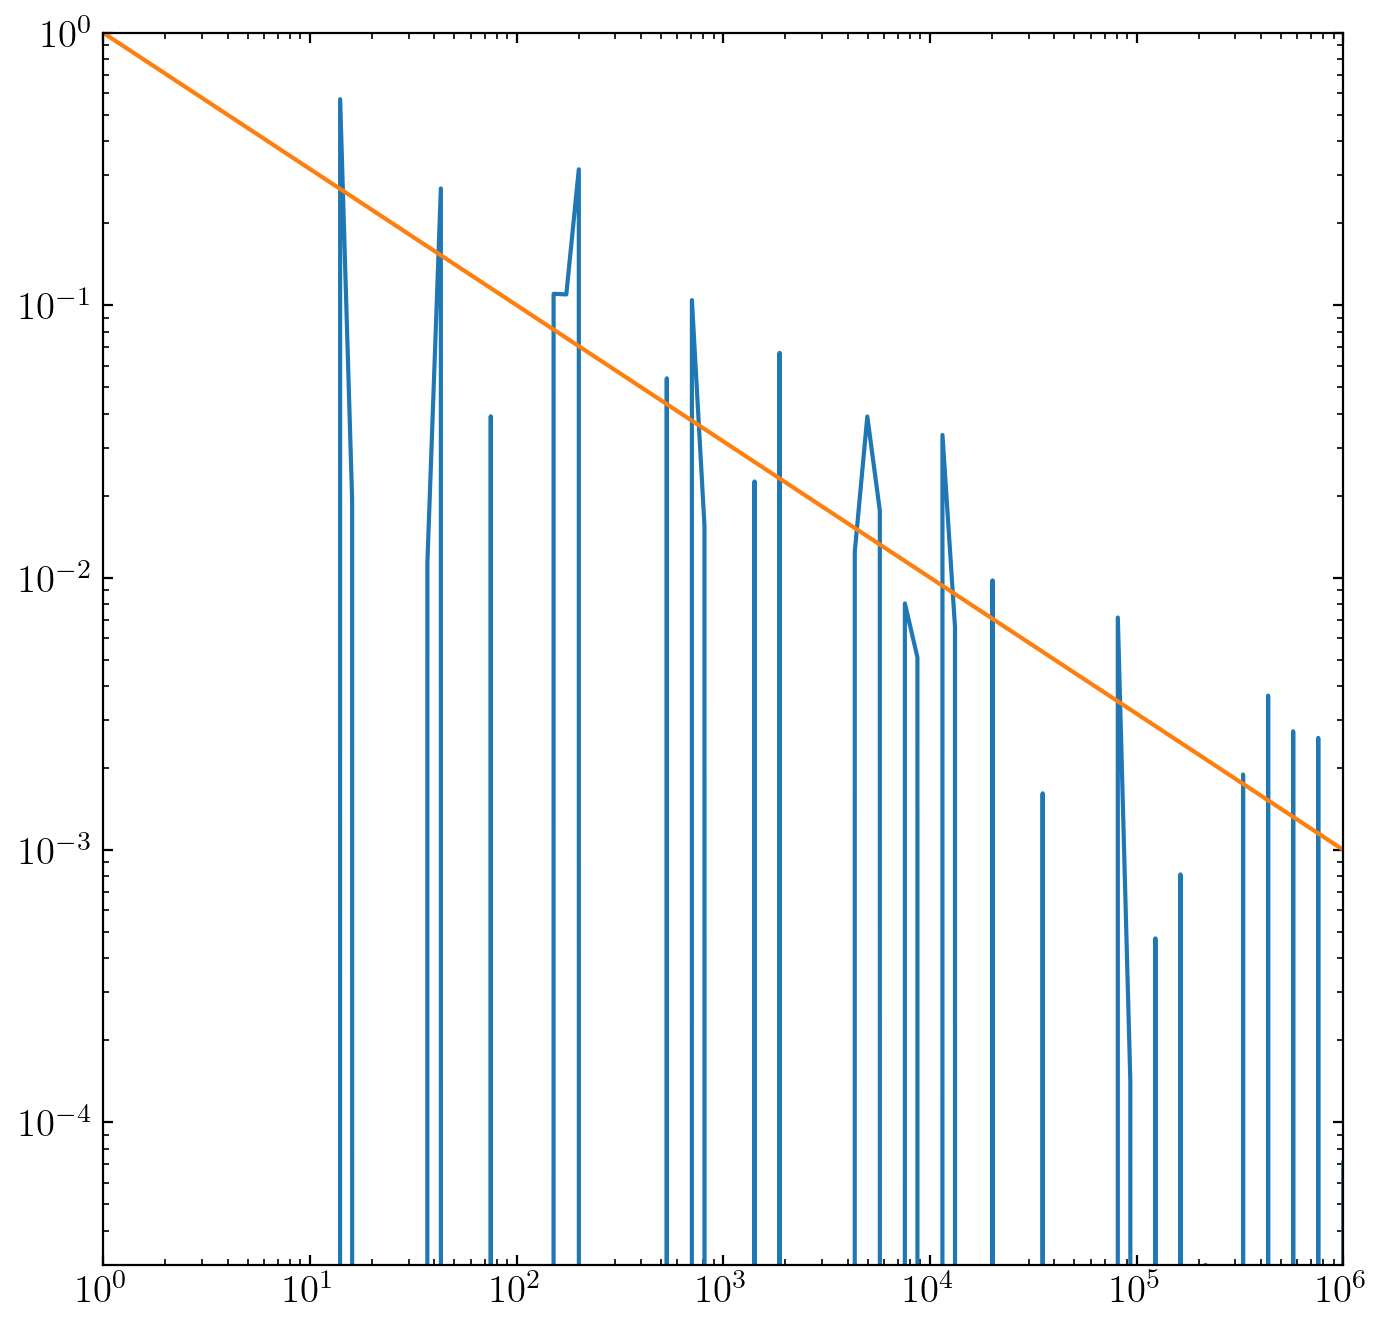

In [8]:


plt.axhline(0,c='red')
plt.plot(Nvals, (results - est_result(sigma))/est_result(sigma))
plt.plot(Nvals, Nvals**-0.5)

plt.loglog()
plt.show()



In [9]:
N = 1000
trials = 10000
results = np.array([integral(sigma,N) for i in tqdm(range(trials))])


  0%|          | 0/10000 [00:00<?, ?it/s]

(array([ 0.21514563,  0.        ,  0.        ,  0.        ,  0.21514563,
         0.21514563,  0.43029126,  0.43029126,  0.43029126,  0.        ,
         0.86058253,  2.36660195,  1.50601942,  2.58174758,  1.93631068,
         4.087767  ,  4.73320389,  4.51805826,  5.80893205,  6.88466021,
         8.60582526,  9.25126216, 10.32699031, 16.78135926, 18.07223305,
        21.72970878, 22.80543694, 23.8811651 , 27.53864084, 35.06873794,
        37.86563115, 40.66252436, 47.7623302 , 49.05320399, 51.63495157,
        56.36815546, 61.96194188, 58.08932051, 64.11339819, 70.13747588,
        63.68310693, 62.82252441, 67.98601956, 75.0858254 , 69.27689335,
        67.98601956, 77.02213609, 64.97398072, 61.74679625, 62.82252441,
        58.73475741, 57.01359235, 56.58330109, 49.05320399, 49.48349525,
        43.88970883, 43.88970883, 34.42330104, 35.4990292 , 37.43533989,
        30.12038841, 24.31145636, 25.17203889, 20.43883499, 19.36310684,
        17.42679615, 18.50252431, 12.04815537, 13.5

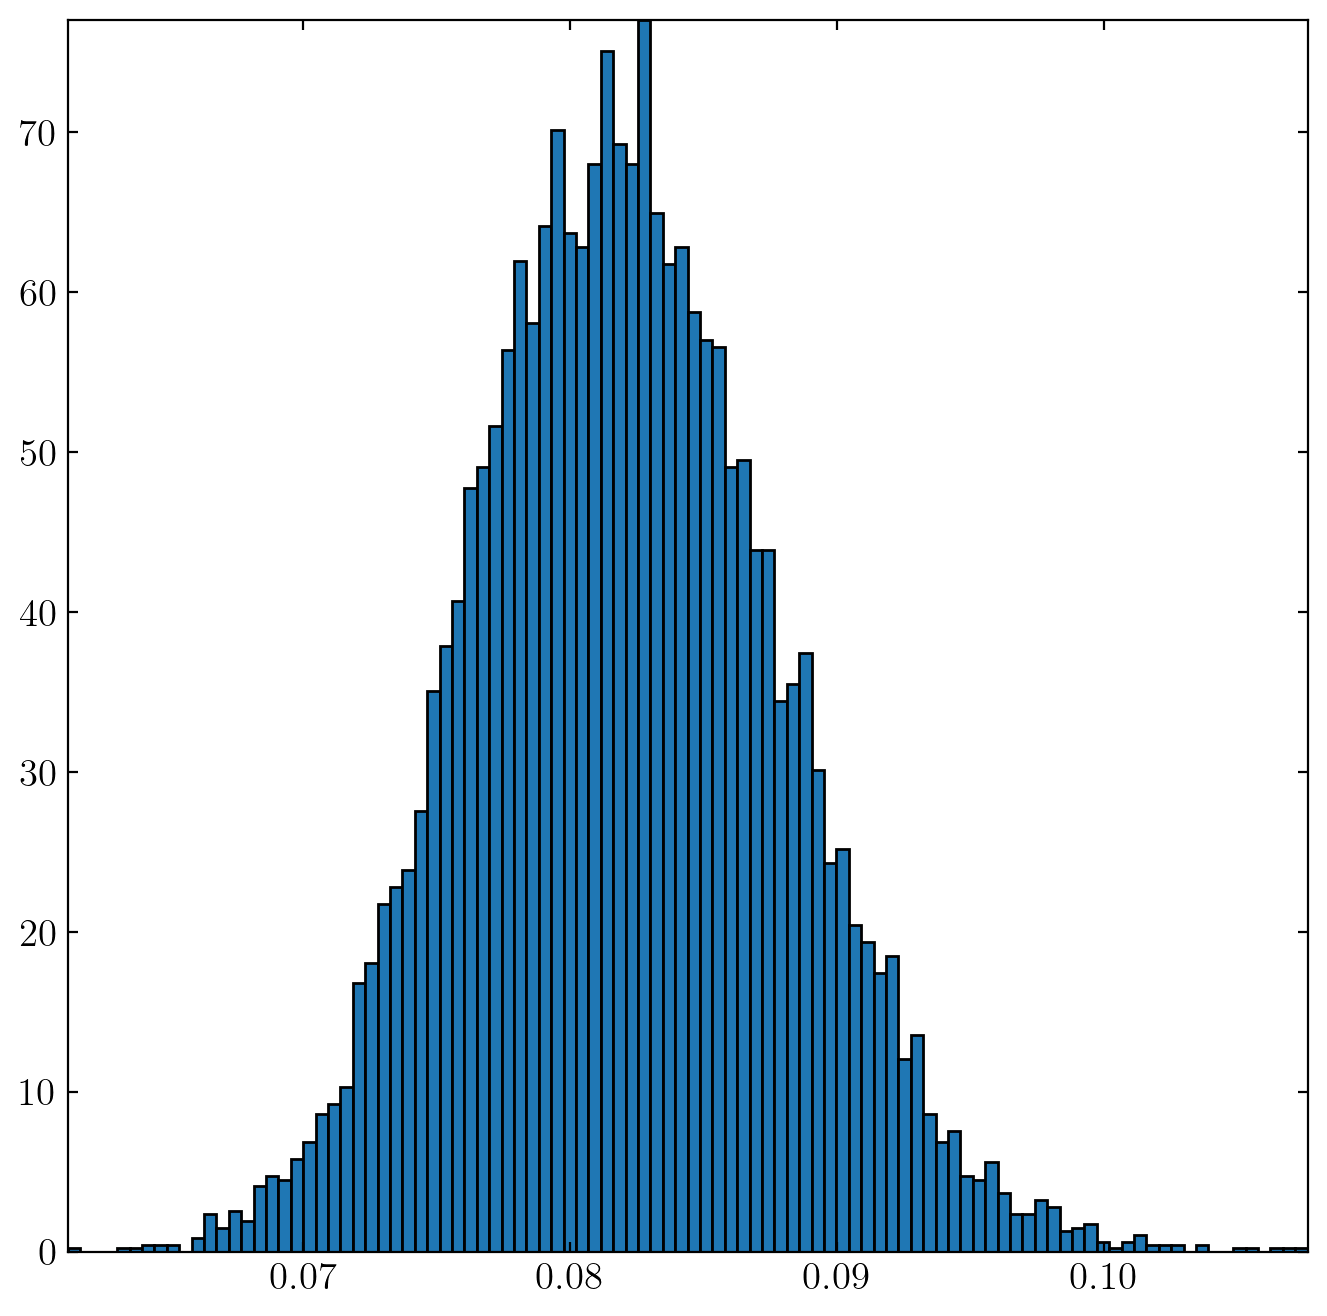

In [10]:
plt.hist(results,density=True, bins=100)

In [11]:
mean = np.average(results)
std = np.std(results, ddof = 1)

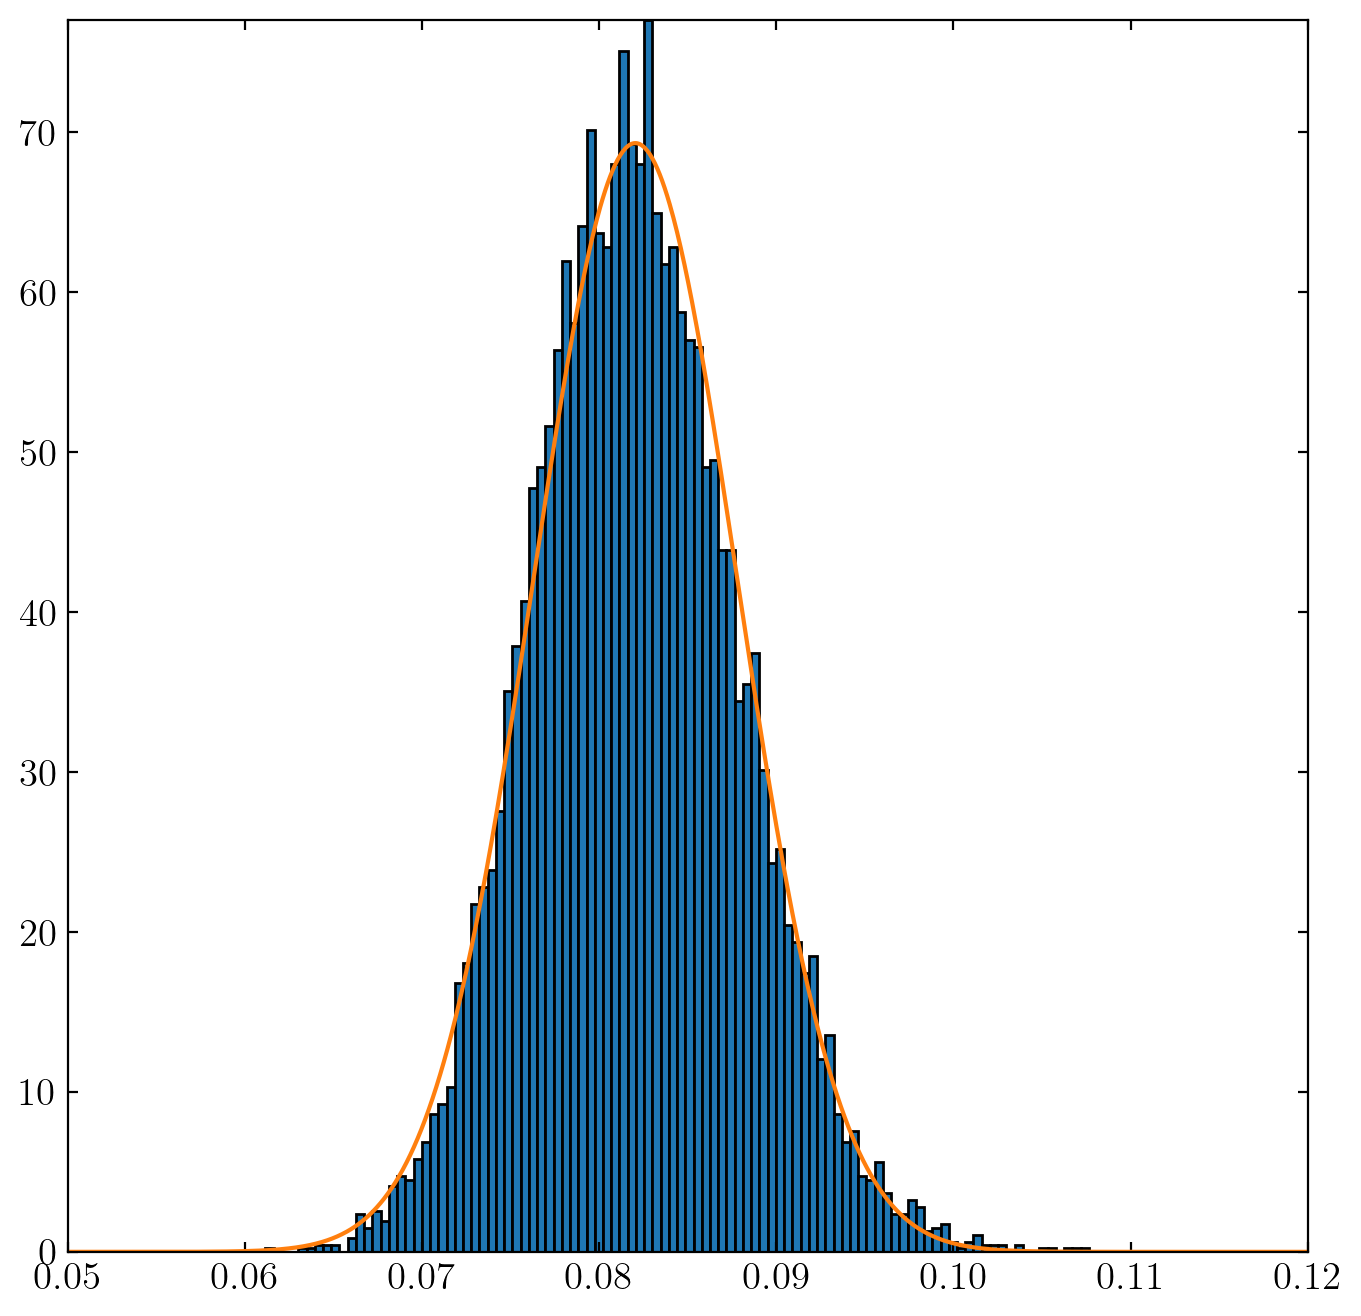

In [12]:


plt.hist(results,density=True, bins=100);
gauss = scipy.stats.norm(loc=mean,scale=std)
x = np.linspace(0.05,0.12,1000)
plt.plot(x,gauss.pdf(x));



In [17]:
trials = 10000
results_matrix = np.zeros((len(N), trials))
for idx, n in enumerate(N):
    print(f"Calcolo riga {idx} (N={n})")
    results_matrix[idx, :] = [integral(sigma, n) for i in tqdm(range(trials))]

Calcolo riga 0 (N=100)


  0%|          | 0/10000 [00:00<?, ?it/s]

Calcolo riga 1 (N=1000)


  0%|          | 0/10000 [00:00<?, ?it/s]

Calcolo riga 2 (N=10000)


  0%|          | 0/10000 [00:00<?, ?it/s]

(array([  1.3391392 ,   0.6695696 ,   1.3391392 ,   2.00870881,
          2.00870881,   2.67827841,   2.00870881,   4.68698722,
          4.68698722,   4.68698722,   3.34784801,  10.71311363,
         11.38268324,  14.06096165,  23.43493608,  20.75665767,
         18.74794886,  26.11321448,  28.12192329,  38.83503693,
         48.20901136,  40.84374573,  59.59169459,  58.25255539,
         85.70490908,  74.99179544, 101.77457953,  93.7397443 ,
        103.11371873, 137.93133805, 122.5312372 , 147.97488208,
        155.3401477 , 168.06197014, 192.83604542, 184.13164059,
        184.13164059, 190.15776701, 215.6014119 , 196.85346304,
        242.38419598, 231.00151275, 219.61882951, 223.63624712,
        219.61882951, 210.24485508, 224.30581672, 215.6014119 ,
        181.45336219, 172.07938776, 160.69670452, 182.12293179,
        141.27918606, 153.3314389 , 123.8703764 , 128.55736362,
         97.08759231, 105.12242754,  93.0701747 ,  84.36576987,
         67.62652982,  58.92212499,  51.

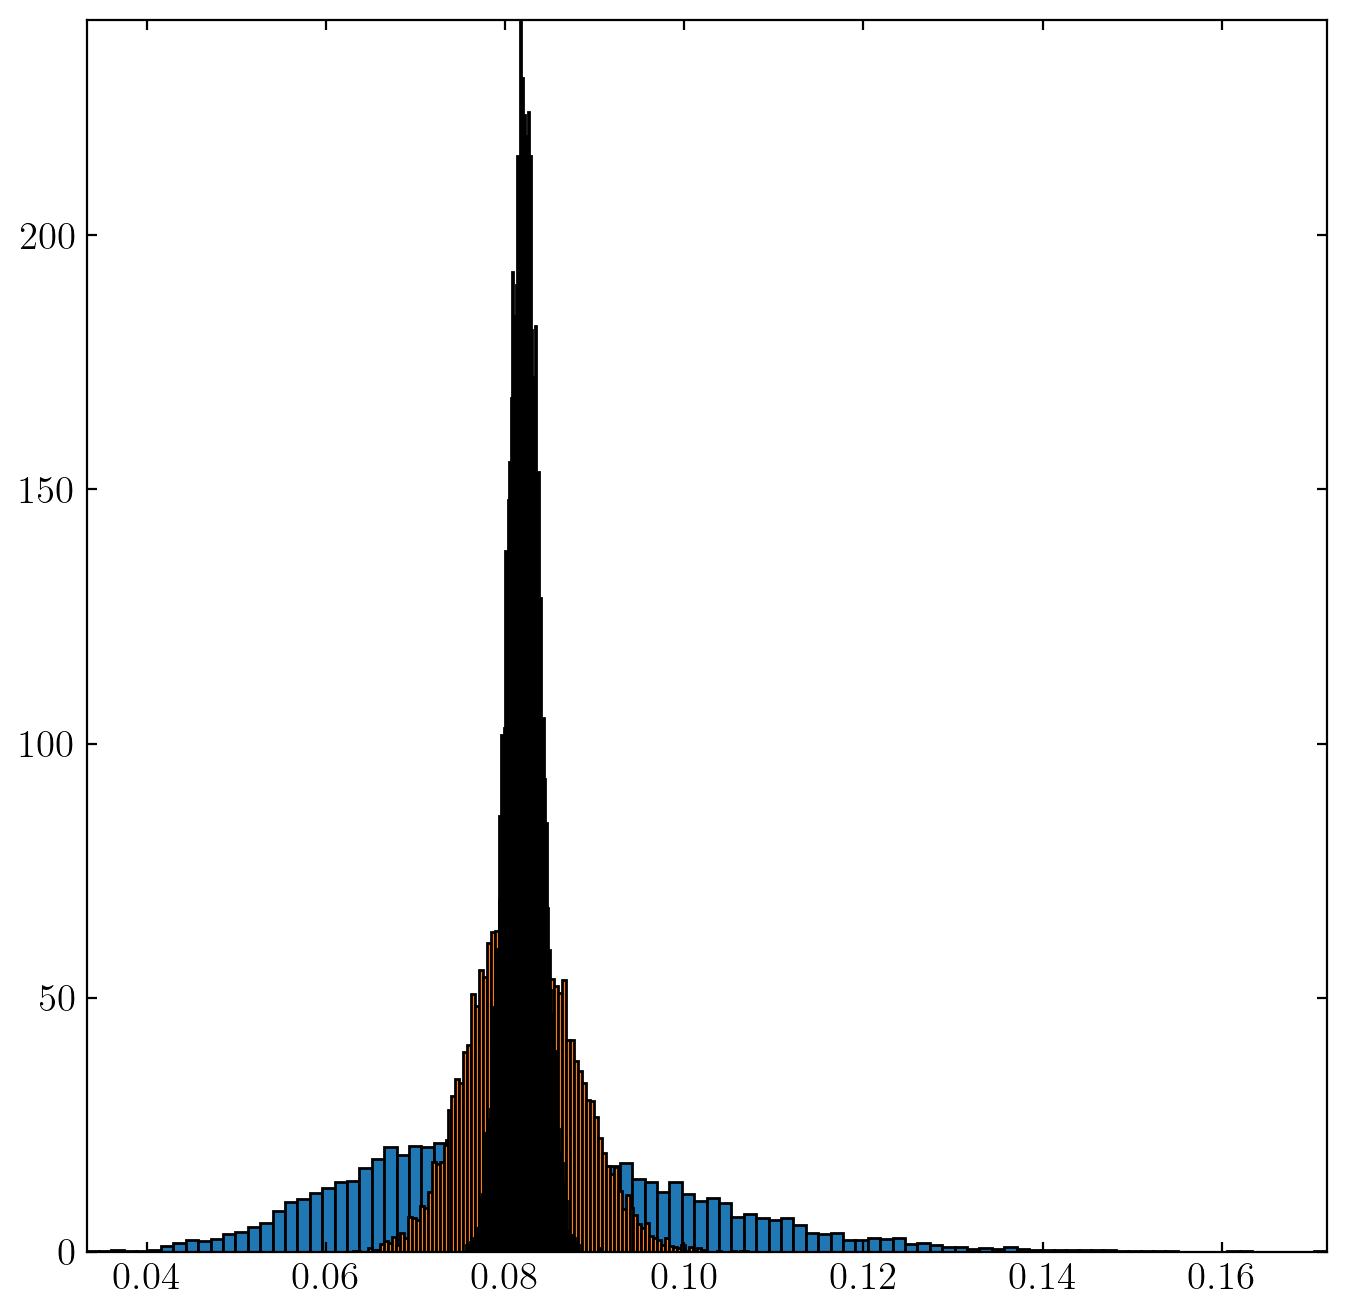

In [27]:
plt.hist(results_matrix[0], density=True, bins=100)
plt.hist(results_matrix[1], density=True, bins=100)
plt.hist(results_matrix[2], density=True, bins=100)

### 2. Kicking horses

A famous early  application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by [Bortkiewicz](https://www.wikiwand.com/en/Ladislaus_Bortkiewicz) in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corpes of 200). He recorded the number of corps with a given number of deaths:

| Number of deaths | Number of groups |
| --- | --- |
| 0 | 109 |
| 1 | 65 |
| 2 | 22 |
| 3 | 3 |
| 4 | 1 |

- Plot the resulting probability distribution. Careful with the normalization
- How does it look like? Again try to fit it by hand.

(Hint: think about sample mean and sample variance)


In [34]:
deaths = [0,1,2,3,4]
groups = [109, 65, 22, 3, 1]
tot = np.sum(groups)
freq = groups/tot


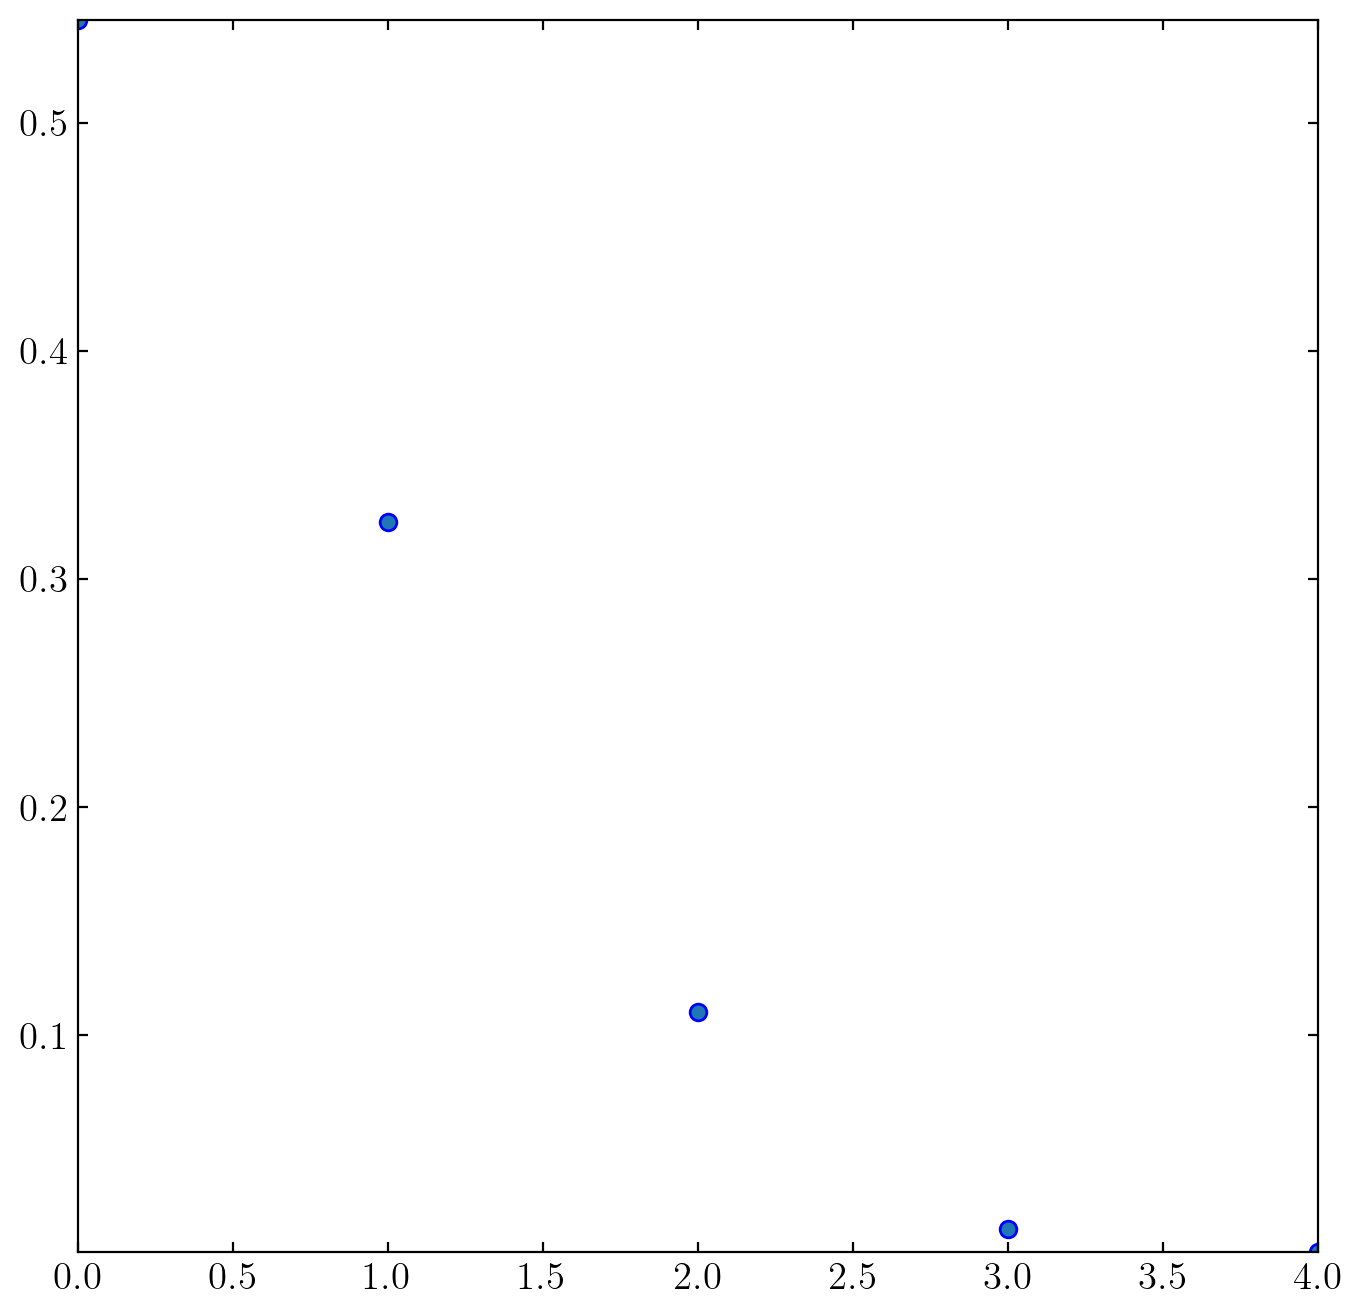

In [35]:
plt.scatter(deaths, freq)

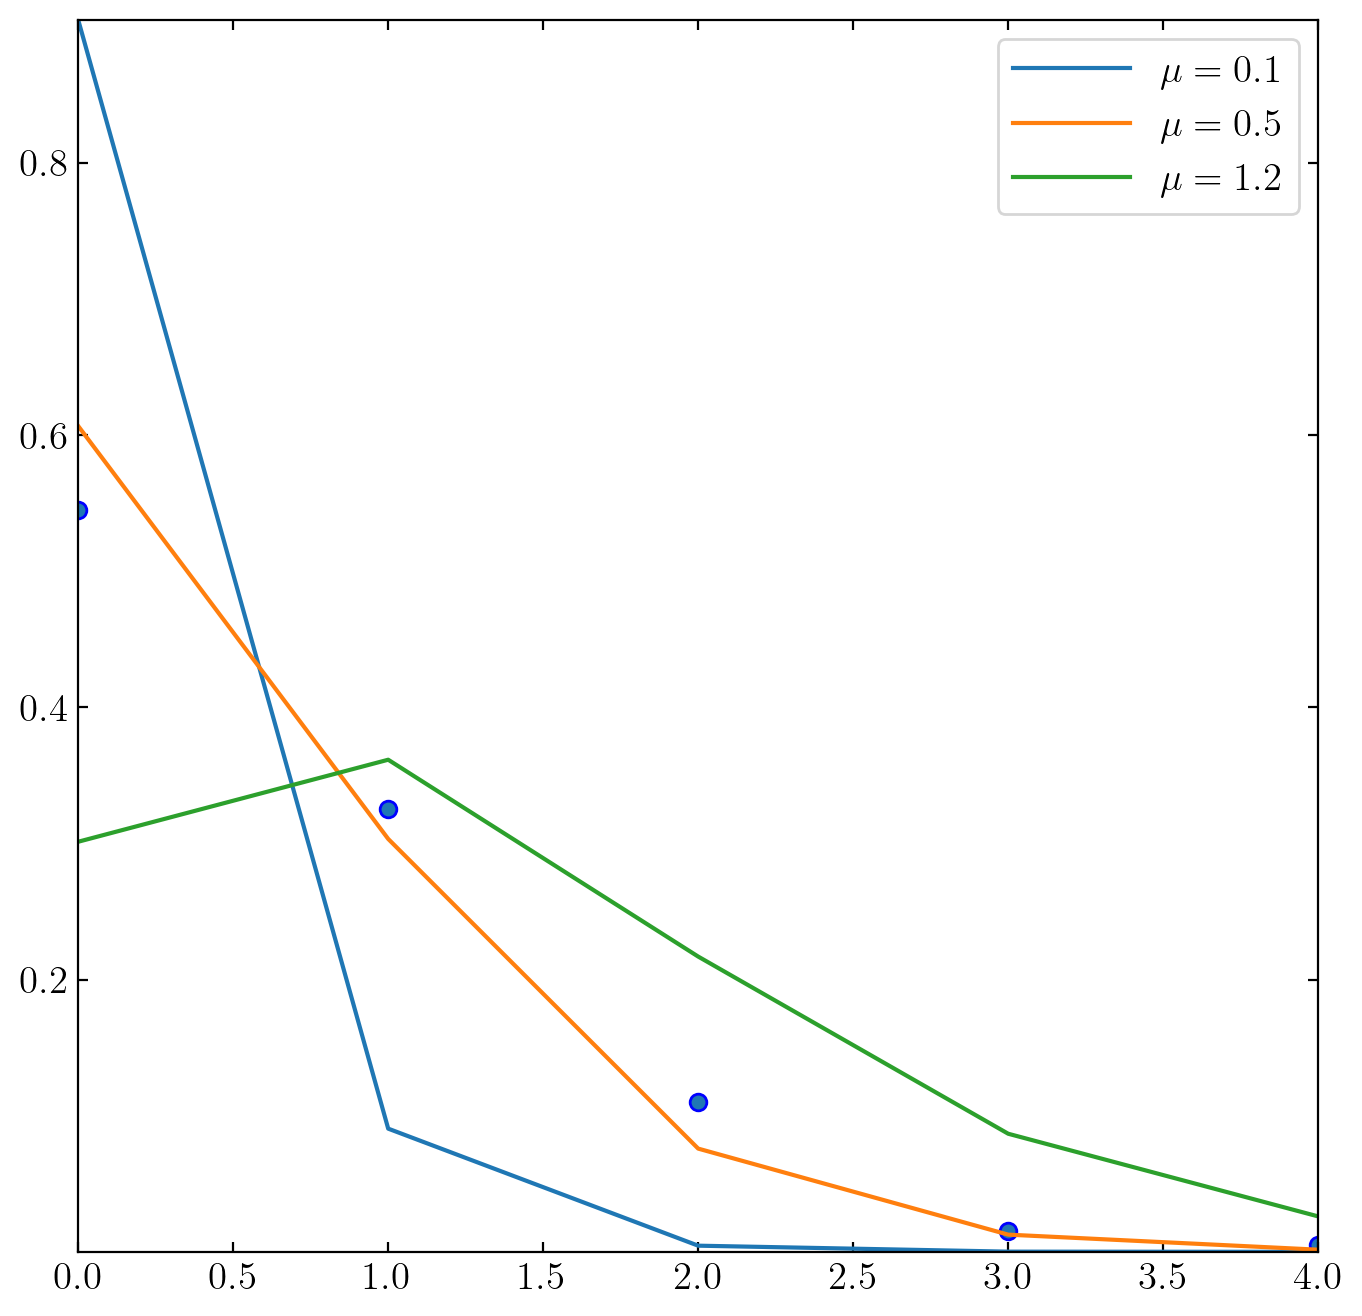

In [39]:
plt.scatter(deaths,freq)
for mu in [0.1, 0.5, 1.2]:
    p = scipy.stats.poisson(mu).pmf(deaths)
    plt.plot(deaths, p, label = '$\mu=' + str(mu) + "$")
plt.legend()

In [40]:
#now use sample mean
goodmu = np.average(deaths, weights = freq)

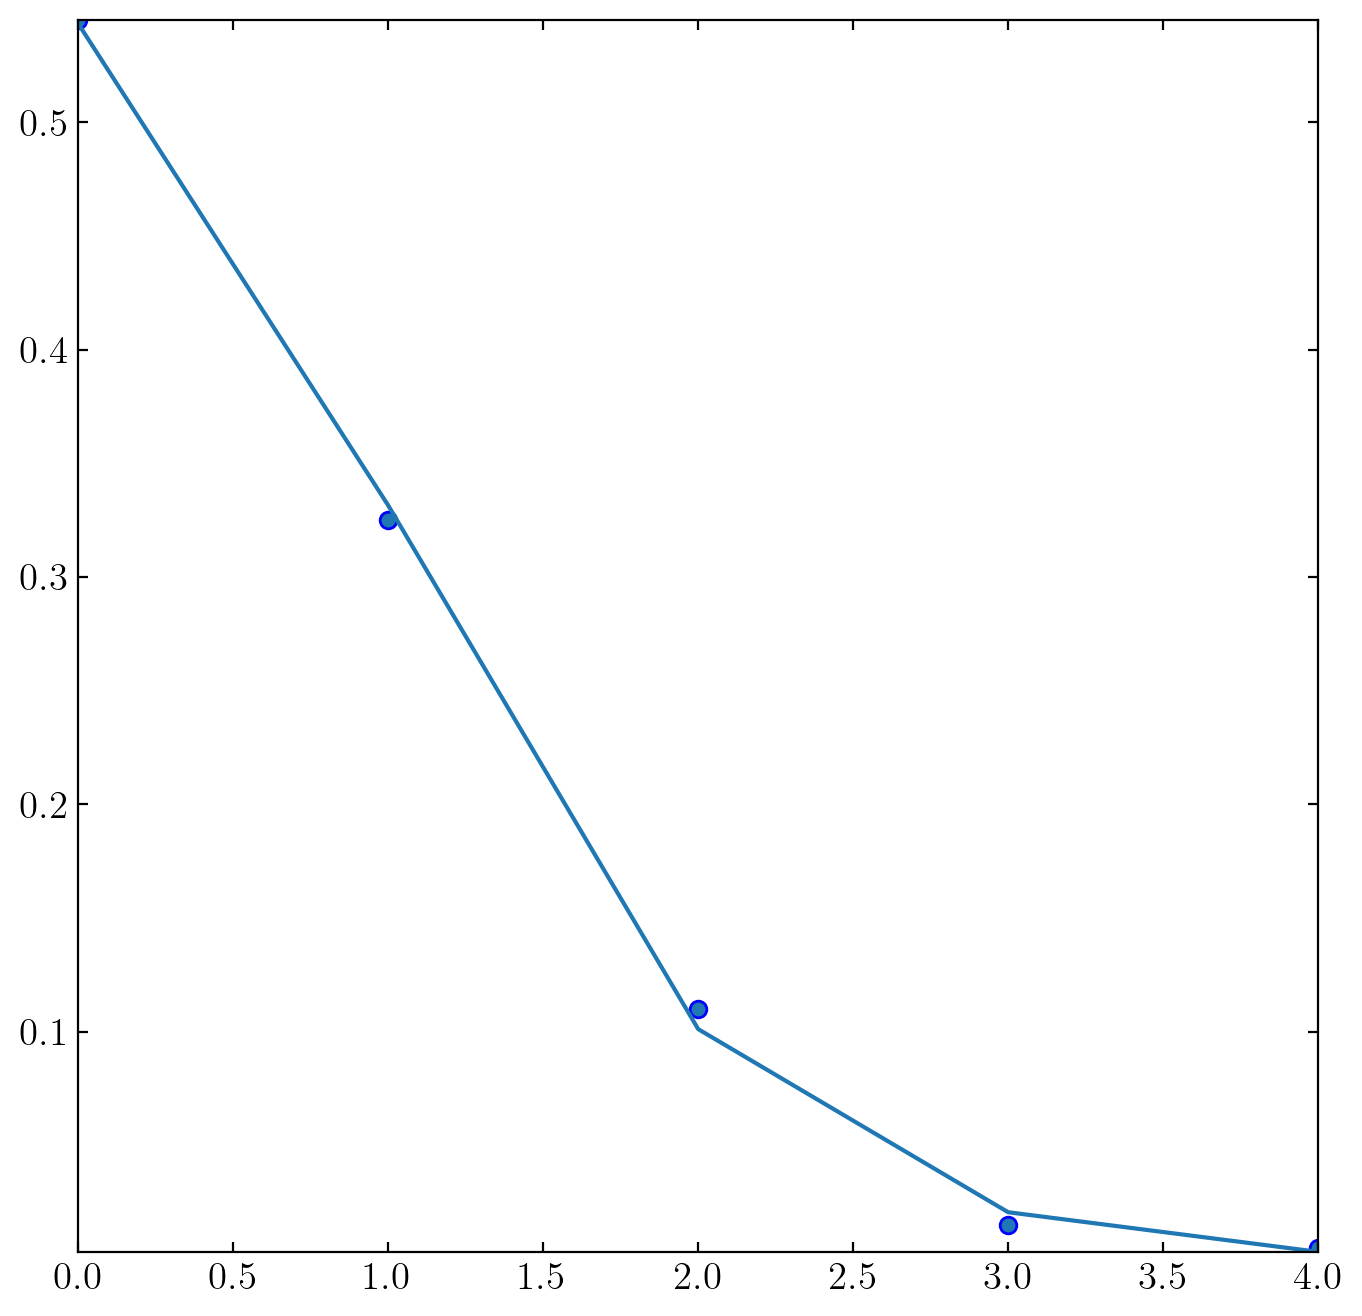

In [42]:
plt.scatter(deaths, freq)

p = scipy.stats.poisson(goodmu).pmf(deaths)
plt.plot(deaths, p)

